# 睡眠品質予測（EDA）
## データの基本情報の確認

In [2]:
import pandas as pd

df = pd.read_csv("data/raw/Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df.shape

(374, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


In [5]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [6]:
# 欠損値の確認
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [7]:
df["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [8]:
# Person IDは予測に関係ないため、削除する。
df = df.drop(columns=["Person ID"])

In [9]:
# 血圧の処理（str型で収縮期血圧と拡張期血圧をなので必要がある）
# 120/80 ←収縮期血圧/拡張期血圧

df[["Systolic", "Diastolic"]] = (
    df["Blood Pressure"]
      .str.split("/", expand=True)
      .astype(int)
)

In [10]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    str    
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    str    
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    str    
 8   Blood Pressure           374 non-null    str    
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    str    
 12  Systolic                 374 non-null    int64  
 13  Diastolic                374 non-null    int64  
dtypes: float64(1), int64(8), str(5)
memor

## 可視化

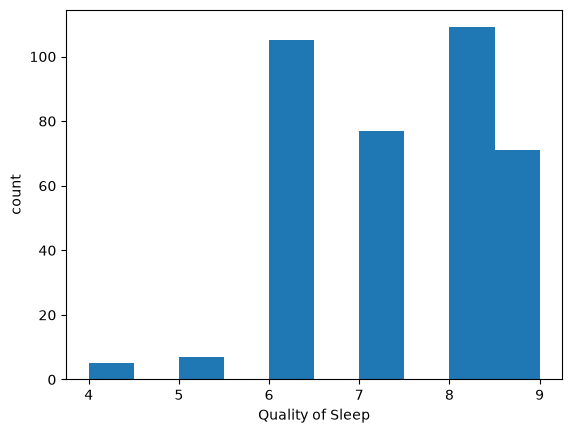

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["Quality of Sleep"])
plt.xlabel("Quality of Sleep")
plt.ylabel("count")
plt.show()

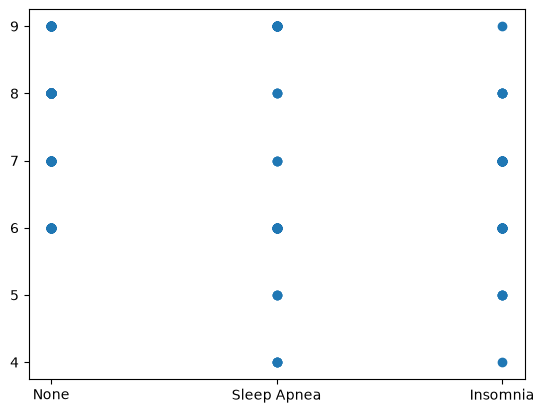

In [13]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
plt.scatter(df["Sleep Disorder"], df["Quality of Sleep"])

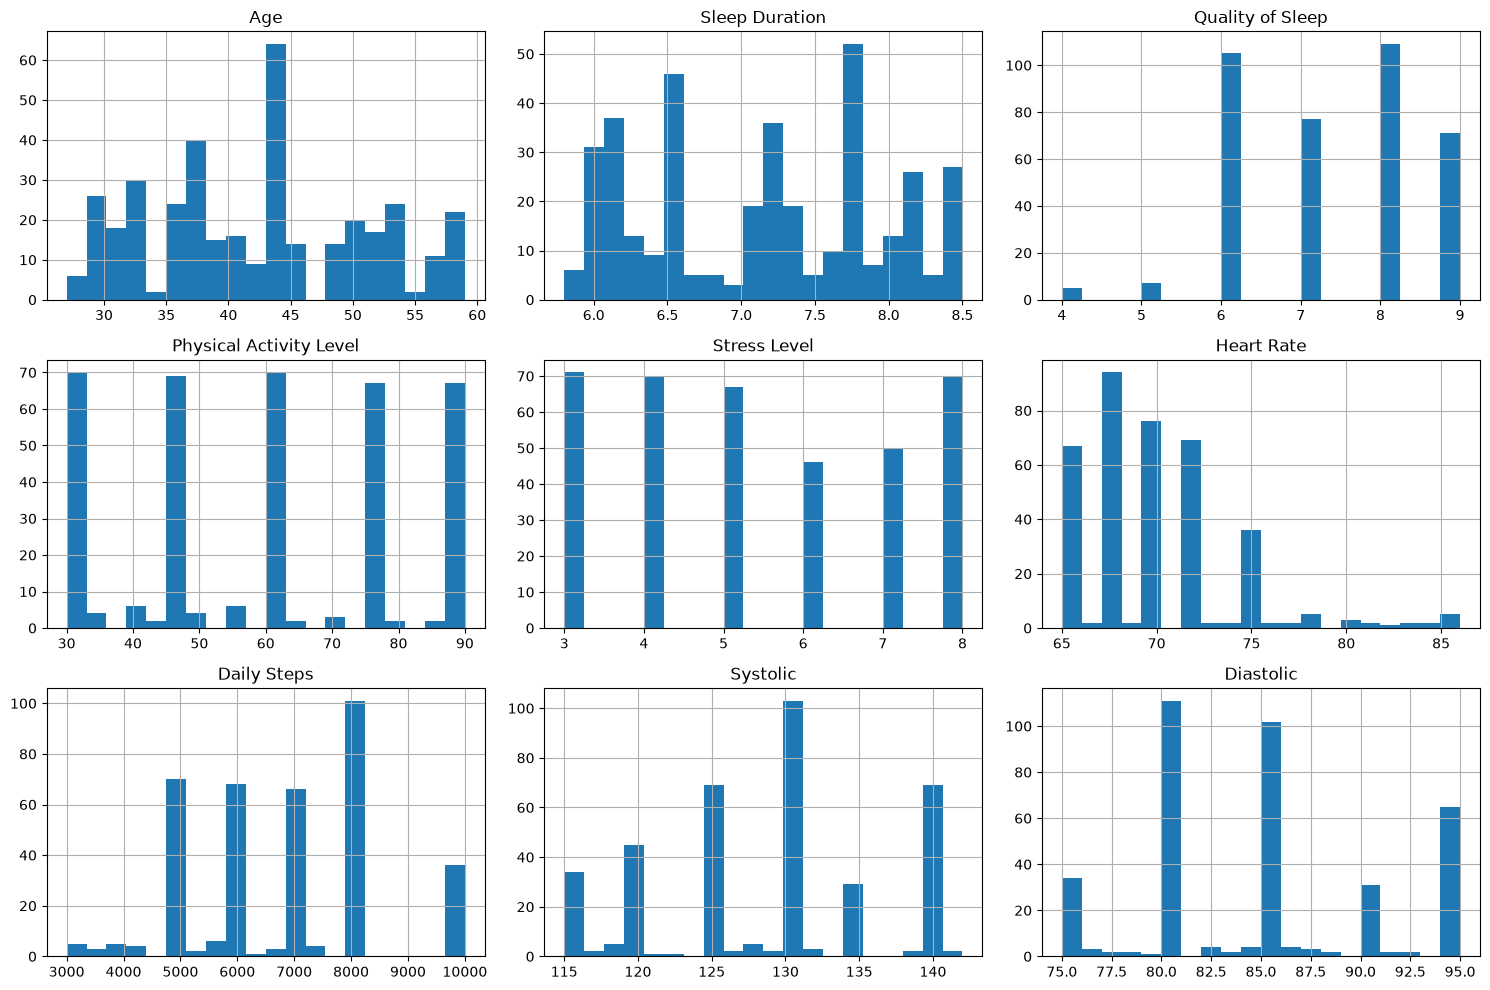

In [14]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

### 目的変数の確認  
このプロジェクトでは睡眠品質を知りたいので、 **Quality of asleep** との相関を調べる。  
このデータから、以下の特徴量が目的変数との相関関係があることが分かった。  
- Age
- Sleep Duration
- Stress Level
- Heart Rate

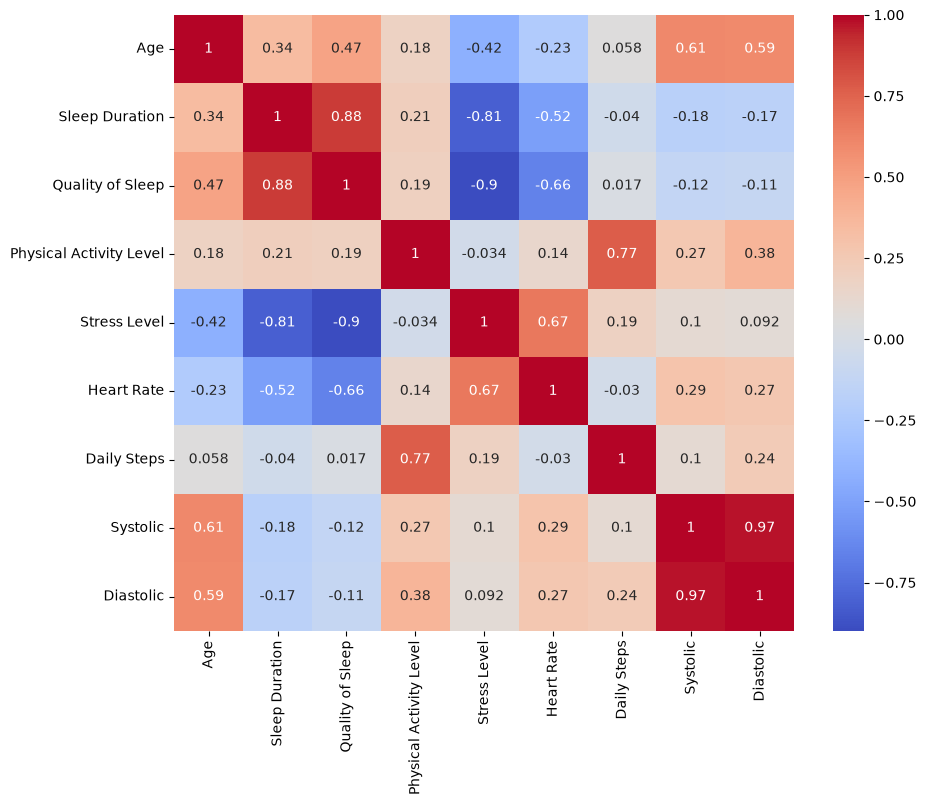

In [17]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

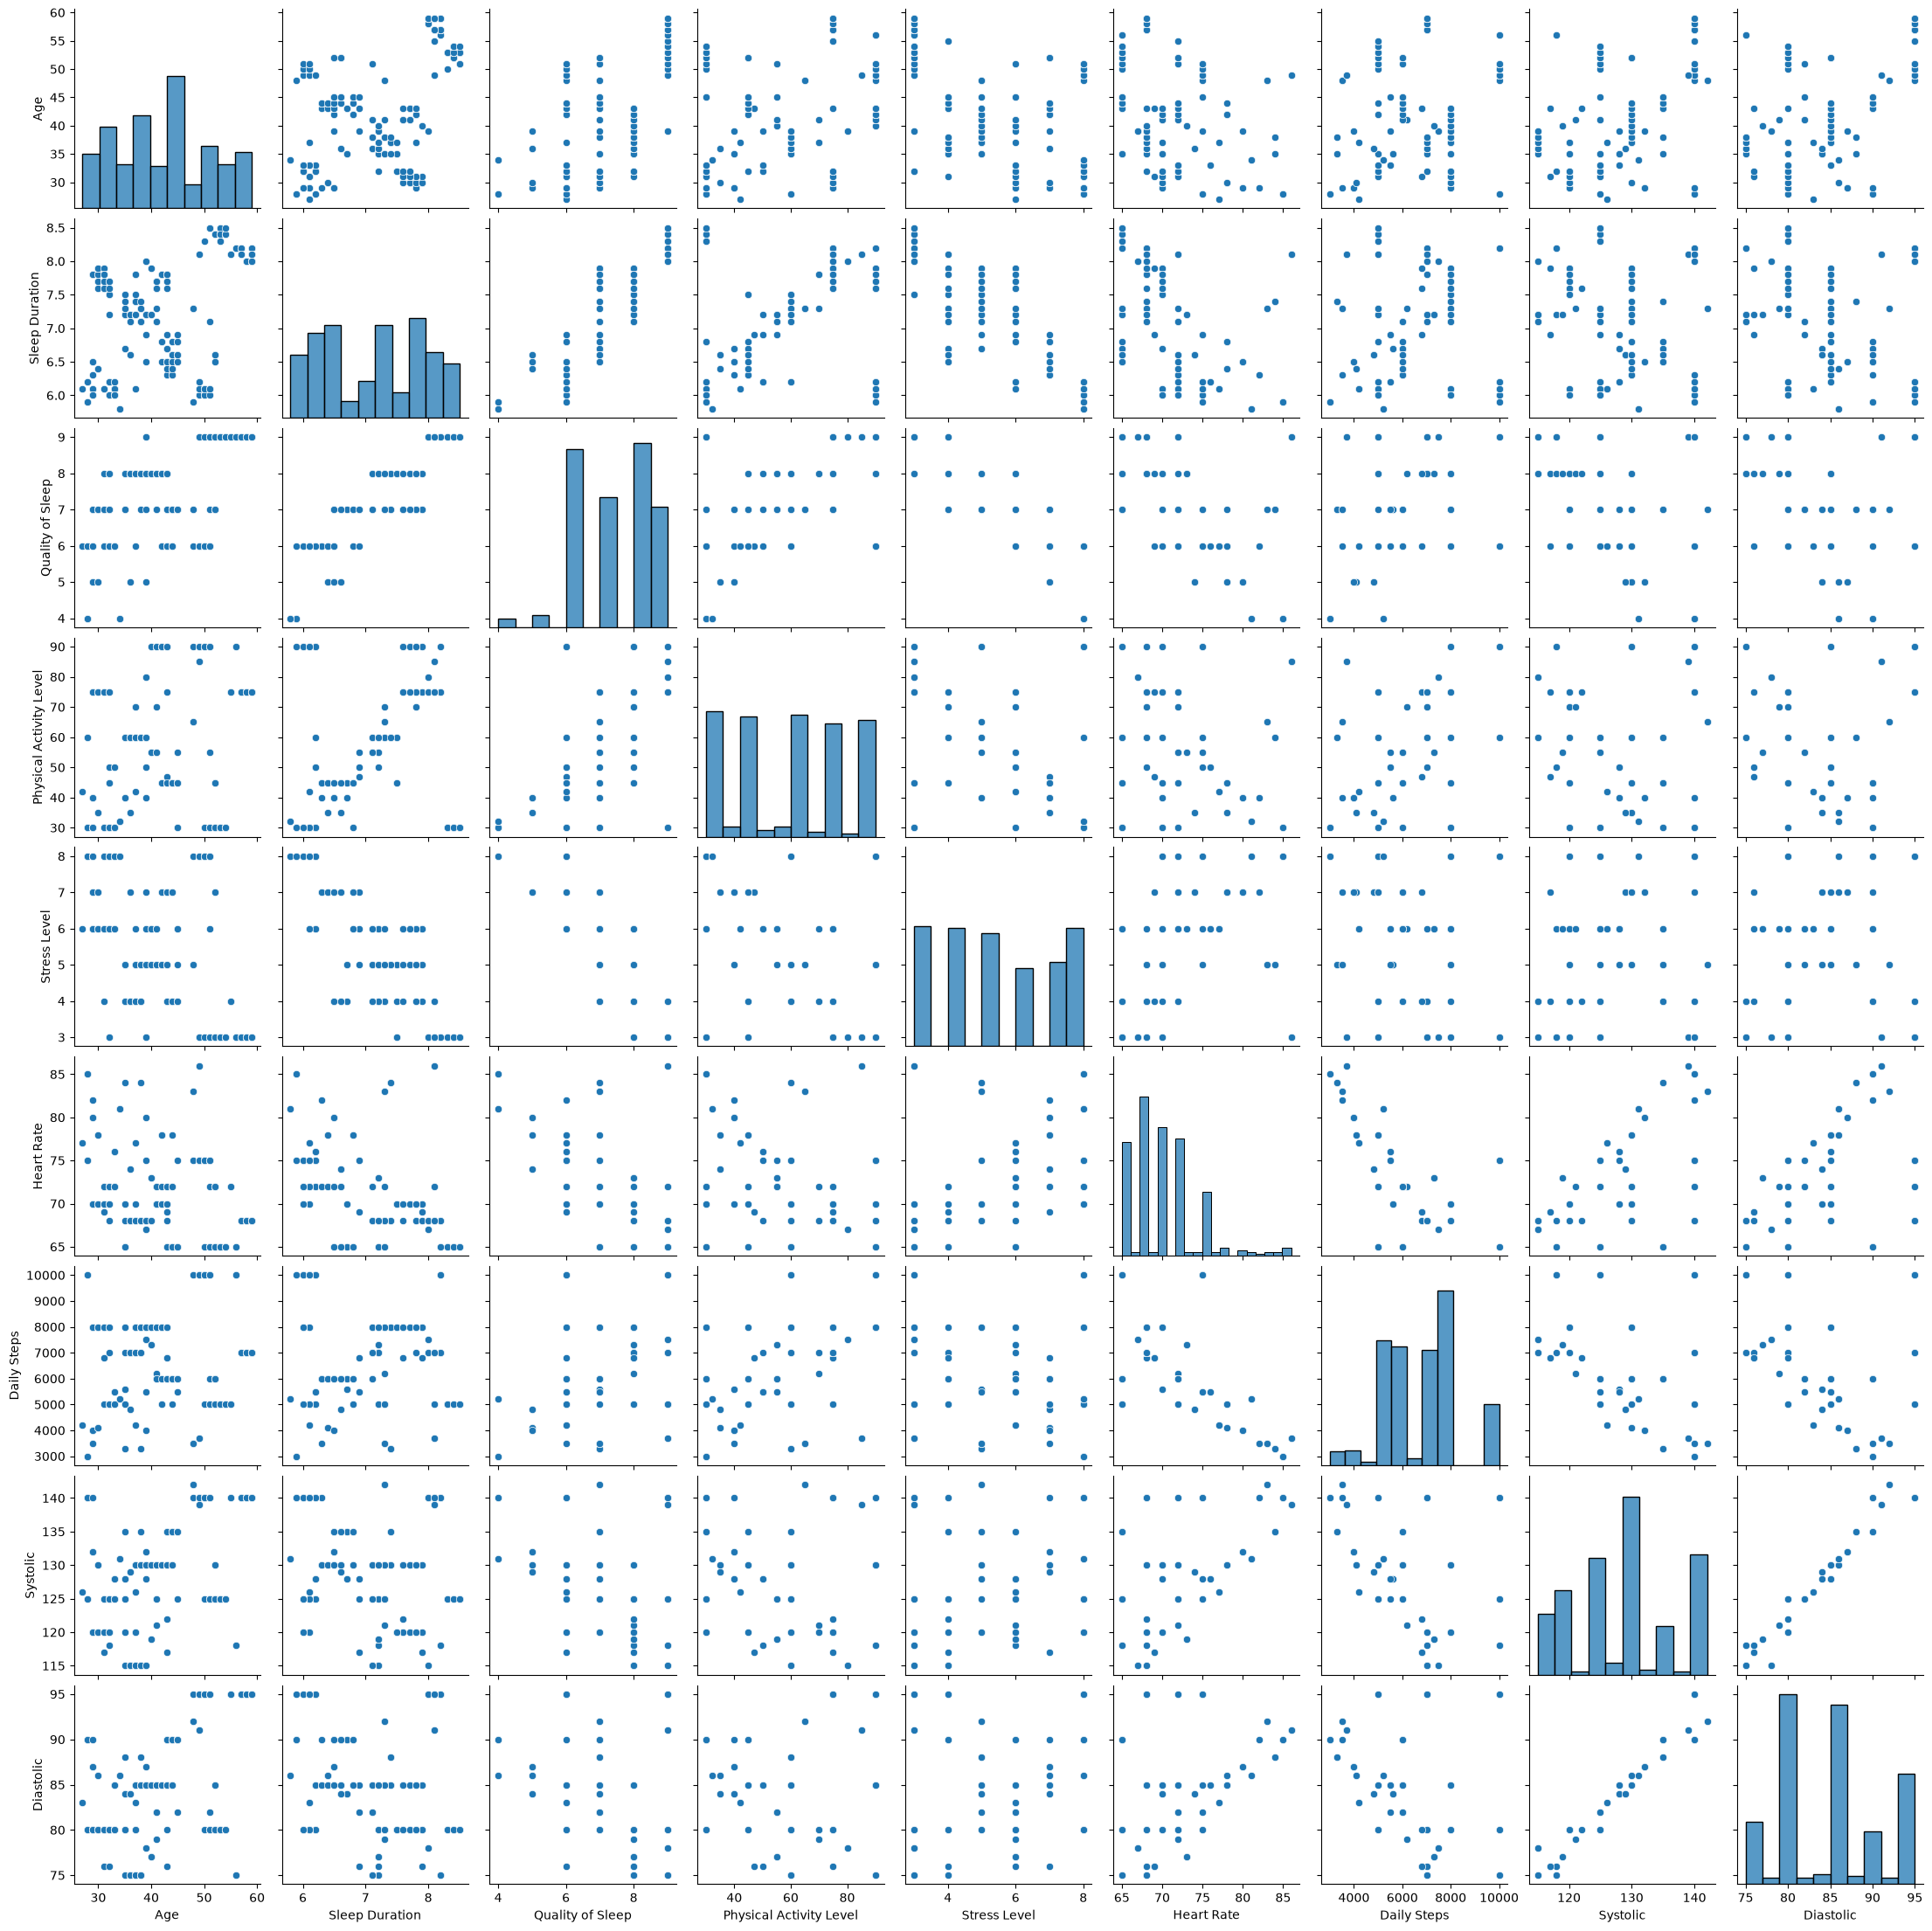

In [60]:
sns.pairplot(df)
plt.show()

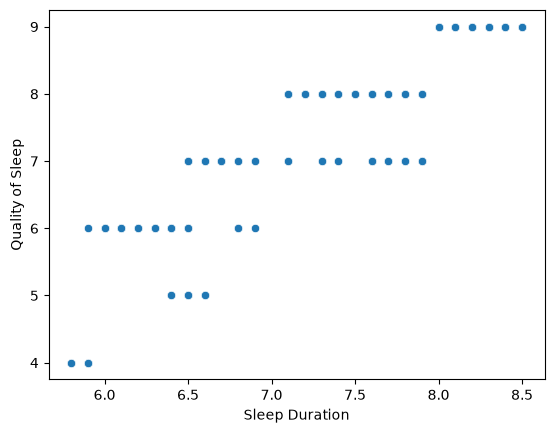

In [61]:
# 睡眠時間との関係
# 相関係数：0.88
sns.scatterplot(
    data=df,
    x="Sleep Duration",
    y="Quality of Sleep"
)
plt.show()

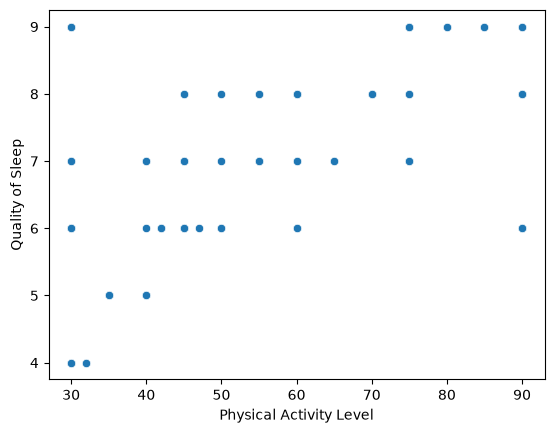

In [30]:
# 運動量との関係
# 相関係数：0.19
sns.scatterplot(
    data=df,
    x="Physical Activity Level",
    y="Quality of Sleep"
)
plt.show()

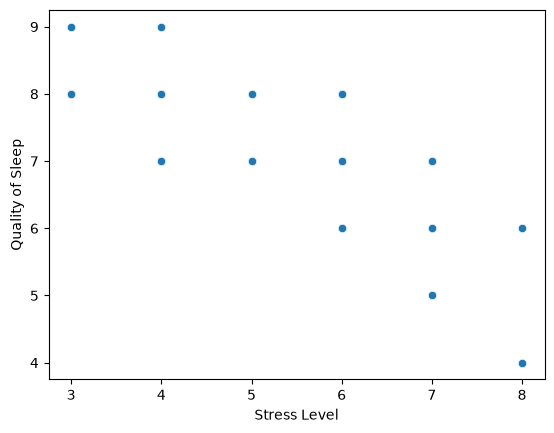

In [27]:
# ストレスとの関係
# 相関係数：-0.9
sns.scatterplot(
    data=df,
    x="Stress Level",
    y="Quality of Sleep"
)
plt.show()

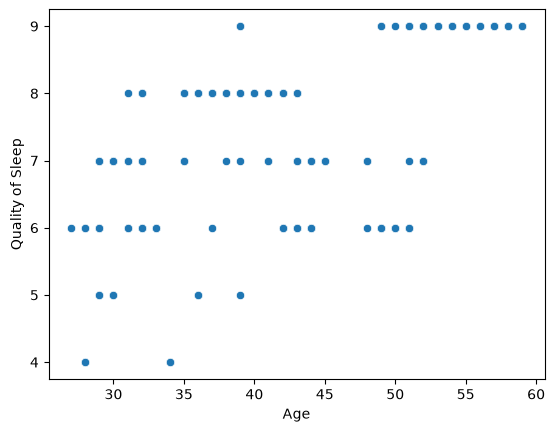

In [28]:
# 年齢との関係
# 相関係数：0.47
sns.scatterplot(
    data=df,
    x="Age",
    y="Quality of Sleep"
)
plt.show()

<Axes: xlabel='Gender', ylabel='Count'>

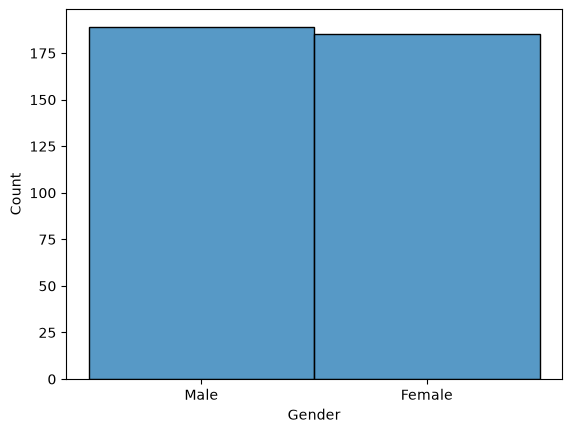

In [29]:
sns.histplot(df, x="Gender")

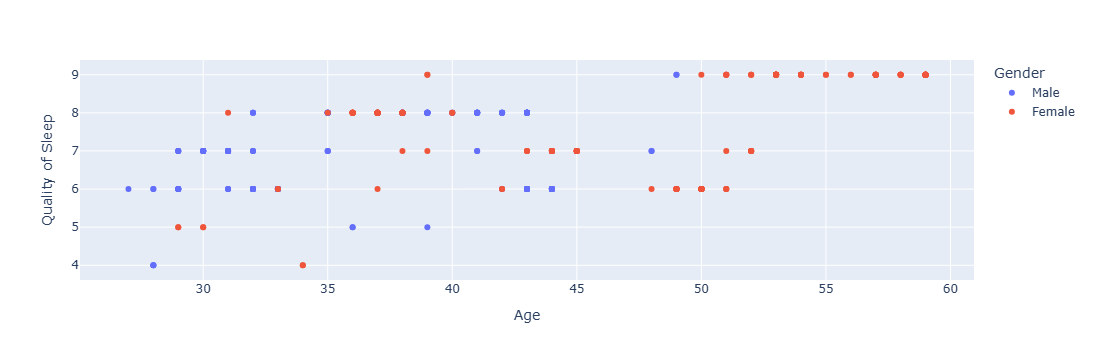

In [26]:
import plotly.express as px

px.scatter(
    df,
    x="Age",
    y="Quality of Sleep",
    color="Gender"
)

# 若い人ほど睡眠の質が悪い（年齢が高いほど睡眠の質が高い）

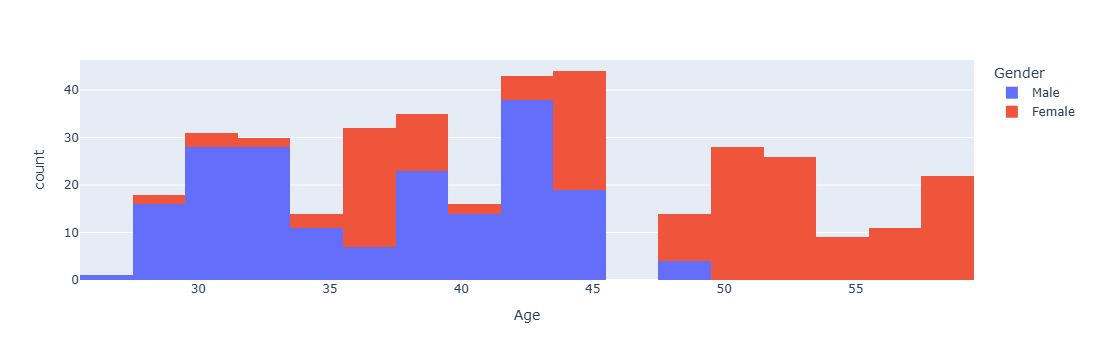

In [27]:
px.histogram(
    df,
    x="Age",
    color="Gender"
)

# 男性は若い人が多い、女性は中年層が多い
# 50歳以上は皆女性

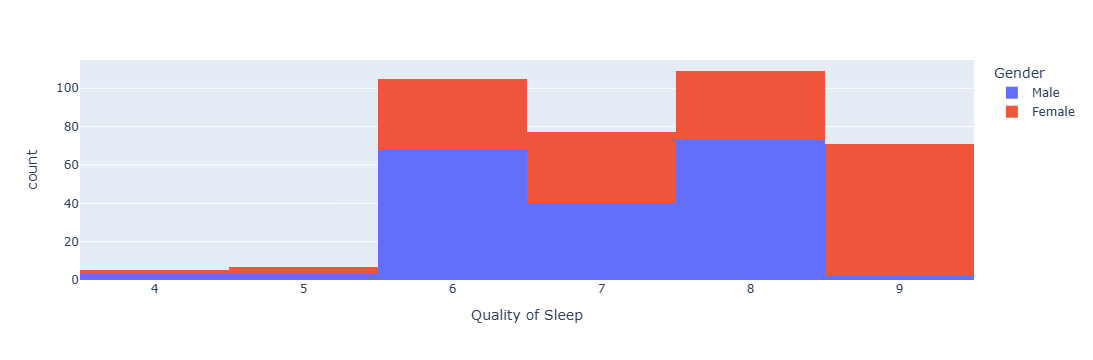

In [28]:
px.histogram(
    df,
    x="Quality of Sleep",
    color="Gender"
)

# 男性は若い人が多い、女性は中年層が多い
# 女性の中年層が一番

BMI Categoryを確認したところ、  
Normal、Overweight、Obeseのカテゴリが存在した一方、  
Underweight（やせ型）のサンプルは確認されなかった。  

そのため本モデルは標準体重以上のサンプルを中心に学習しており、  
低体重者に対する予測性能には注意が必要である。

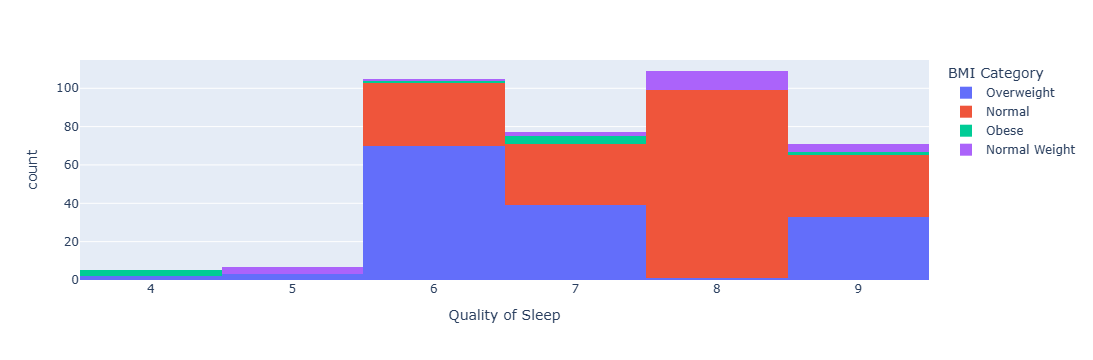

In [29]:
px.histogram(
    df,
    x="Quality of Sleep",
    color="BMI Category"
)

# 男性は若い人が多い、女性は中年層が多い
# 女性の中年層が一番

睡眠障害はない方が睡眠品質が高い。  
障害ある場合でも睡眠品質が良い場合もあるが、  
低品質では皆障害ありとなっている。

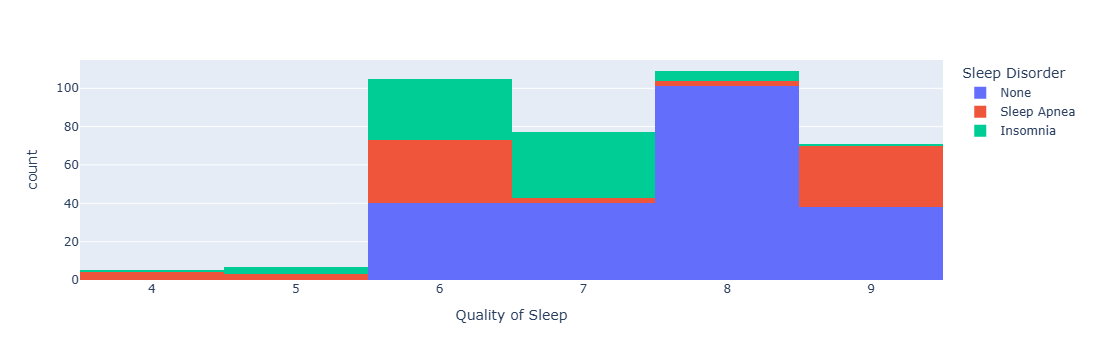

In [30]:
px.histogram(
    df,
    x="Quality of Sleep",
    color="Sleep Disorder"
)

# 男性は若い人が多い、女性は中年層が多い
# 女性の中年層が一番

In [22]:
df["Occupation"].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [23]:
df["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [24]:
df["BMI Category"].value_counts()

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

### 特徴量に入れた方がいいもの
- Age
- Stress Level
- Gender
- 

In [32]:
df.groupby("Gender")["Quality of Sleep"].mean()

Gender
Female    7.664865
Male      6.968254
Name: Quality of Sleep, dtype: float64

In [33]:
df.groupby("Age")["Quality of Sleep"].mean()

Age
27    6.000000
28    4.800000
29    6.153846
30    6.692308
31    6.888889
32    6.529412
33    6.000000
34    4.000000
35    7.750000
36    7.500000
37    7.900000
38    7.950000
39    7.866667
40    8.000000
41    7.833333
42    7.333333
43    7.088235
44    6.400000
45    7.000000
48    6.666667
49    6.545455
50    6.150000
51    7.625000
52    7.666667
53    9.000000
54    9.000000
55    9.000000
56    9.000000
57    9.000000
58    9.000000
59    9.000000
Name: Quality of Sleep, dtype: float64

In [34]:
df.groupby("Age").size()

Age
27     1
28     5
29    13
30    13
31    18
32    17
33    13
34     2
35    12
36    12
37    20
38    20
39    15
40     4
41    12
42     9
43    34
44    30
45    14
48     3
49    11
50    20
51     8
52     9
53    17
54     7
55     2
56     2
57     9
58     6
59    16
dtype: int64

In [35]:

df[df["Age"] >= 53][
    [
        "Age",
        "Gender",
        "Quality of Sleep",
        "Occupation"
    ]
]


,Age,Gender,Quality of Sleep,Occupation
315,53,Female,9,Engineer
316,53,Female,9,Engineer
317,53,Female,9,Engineer
318,53,Female,9,Engineer
319,53,Female,9,Engineer
320,53,Female,9,Engineer
321,53,Female,9,Engineer
322,53,Female,9,Engineer
323,53,Female,9,Engineer
324,53,Female,9,Engineer


In [39]:
# 職業による睡眠品質の平均

df.groupby("Occupation")["Quality of Sleep"].agg(["mean", "count"]).sort_values("mean", ascending=False)

# 結論：アプリに入れなくていい
# 理由：職種ごとににんずうが多いものもあればかなり少ないものもあるので、職種との関係性をはっきり決めれない。
# また、職種は簡単に変えられるものではないし、改善アドバイスに繋がらない。

,mean,count
Occupation,,
Engineer,8.412698,63
Lawyer,7.893617,47
Accountant,7.891892,37
Nurse,7.369863,73
Manager,7.000000,1
Teacher,6.975000,40
Doctor,6.647887,71
Software Engineer,6.500000,4
Salesperson,6.000000,32


In [40]:
df.groupby(
    "BMI Category"
)["Quality of Sleep"].mean()

BMI Category
Normal           7.661538
Normal Weight    7.428571
Obese            6.400000
Overweight       6.898649
Name: Quality of Sleep, dtype: float64

In [41]:
# BMI統一
df["BMI Category"] = df["BMI Category"].replace(
    {
        "Normal Weight": "Normal"
    }
)

## モデル比較

In [43]:
X = df.drop(columns=["Quality of Sleep"])
y = df["Quality of Sleep"]

In [44]:
categorical_features = [
    "Gender",
    "Occupation",
    "BMI Category",
    "Sleep Disorder"
]

numerical_features = [
    "Age",
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic",
    "Diastolic"
]

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [48]:
from sklearn.pipeline import Pipeline

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

results = []

for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3)
    })

results_df = pd.DataFrame(results)

results_df.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
2,GradientBoosting,0.03,0.129,0.989
1,RandomForest,0.04,0.137,0.988
0,LinearRegression,0.12,0.225,0.966


In [50]:
# 全特徴量含む
features_all = [
    "Age",
    "Gender",
    "Occupation",
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "BMI Category",
    "Heart Rate",
    "Daily Steps",
    "Sleep Disorder",
    "Systolic",
    "Diastolic"
]

# Occupation無し
features_no_occupation = [
    "Age",
    "Gender",
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "BMI Category",
    "Heart Rate",
    "Daily Steps",
    "Sleep Disorder",
    "Systolic",
    "Diastolic"
]

# アプリ向け
features_app = [
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "BMI Category",
    "Heart Rate",
    "Daily Steps"
]

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import numpy as np

In [52]:
def evaluate_feature_set(
    df,
    features,
    models
):
    X = df[features]
    y = df["Quality of Sleep"]

    categorical_features = X.select_dtypes(
        include=["object"]
    ).columns.tolist()

    numerical_features = X.select_dtypes(
        exclude=["object"]
    ).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            ),
            (
                "num",
                "passthrough",
                numerical_features
            )
        ]
    )

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )
    )

    results = []

    for name, model in models.items():

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        pred = pipeline.predict(X_test)

        results.append({
            "Model": name,
            "MAE": mean_absolute_error(
                y_test,
                pred
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_test,
                    pred
                )
            ),
            "R2": r2_score(
                y_test,
                pred
            )
        })

    return pd.DataFrame(results)


In [56]:
# features_all
evaluate_feature_set(
    df,
    features_all,
    models
)

/tmp/ipykernel_5889/4131352388.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


,Model,MAE,RMSE,R2
0,LinearRegression,0.119769,0.225104,0.966412
1,RandomForest,0.040133,0.137244,0.987514
2,GradientBoosting,0.029980,0.128924,0.988982


In [57]:
# features_no_occupation
evaluate_feature_set(
    df,
    features_no_occupation,
    models
)

/tmp/ipykernel_5889/4131352388.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


,Model,MAE,RMSE,R2
0,LinearRegression,0.194508,0.252383,0.957778
1,RandomForest,0.036800,0.118603,0.990676
2,GradientBoosting,0.022518,0.081505,0.995597


In [58]:
# features_app
evaluate_feature_set(
    df,
    features_app,
    models
)

/tmp/ipykernel_5889/4131352388.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


,Model,MAE,RMSE,R2
0,LinearRegression,0.281028,0.381801,0.903374
1,RandomForest,0.032744,0.086719,0.995015
2,GradientBoosting,0.026248,0.061123,0.997524


In [59]:
corr["Quality of Sleep"].sort_values(ascending=False)


Quality of Sleep           1.000000
Sleep Duration             0.883213
Age                        0.473734
Physical Activity Level    0.192896
Daily Steps                0.016791
Diastolic                 -0.110151
Systolic                  -0.121632
Heart Rate                -0.659865
Stress Level              -0.898752
Name: Quality of Sleep, dtype: float64

In [94]:
# Sleep Duration無し
no_Sleep_Duration = [
    "Physical Activity Level",
    "Stress Level",
    "BMI Category",
    "Heart Rate",
    "Daily Steps"
]

In [95]:
evaluate_feature_set(
    df,
    no_Sleep_Duration,
    models
)

/tmp/ipykernel_5889/4131352388.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


,Model,MAE,RMSE,R2
0,LinearRegression,0.309488,0.400362,0.893751
1,RandomForest,0.052983,0.135821,0.987772
2,GradientBoosting,0.042316,0.114702,0.991279


## 特徴量重要度確認

In [96]:
X = df[features_app]
y = df["Quality of Sleep"]

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print(categorical_features)
print(numerical_features)

['BMI Category']
['Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']


/tmp/ipykernel_5889/2384545081.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [97]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Sleep Duration','Physical Activity Level','Stress Level','BMI Category', 'Heart Rate','Daily Steps']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

In [100]:
feature_names = (
    pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    pipeline
    .named_steps["model"]
    .feature_importances_
)

print(len(importances))

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df

8


,Feature,Importance
3,num__Sleep Duration,0.820350
5,num__Stress Level,0.127911
6,num__Heart Rate,0.027497
7,num__Daily Steps,0.016247
4,num__Physical Activity Level,0.004351
0,cat__BMI Category_Normal,0.003251
1,cat__BMI Category_Obese,0.000377
2,cat__BMI Category_Overweight,0.000016


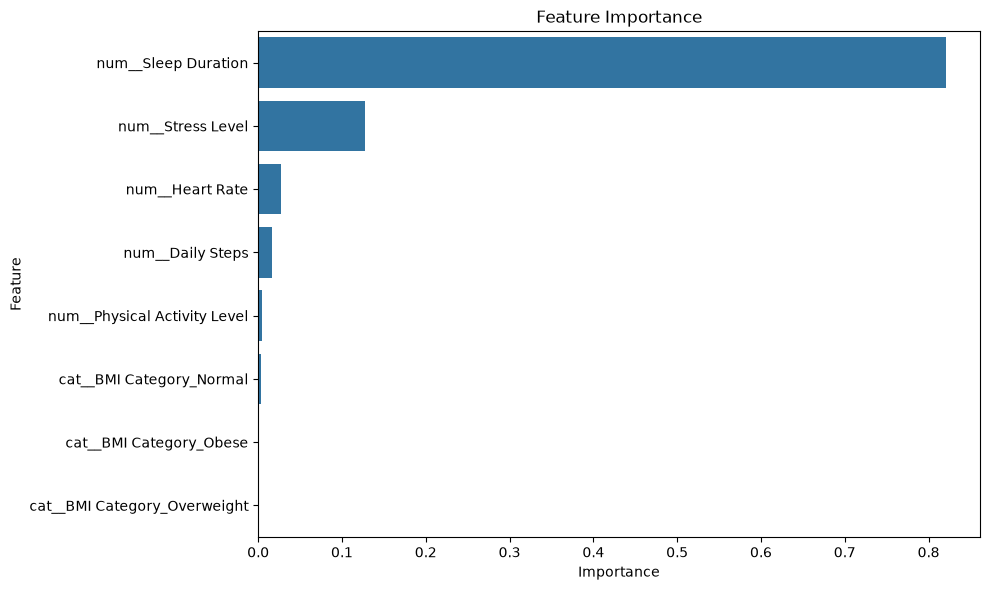

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [102]:
import joblib

joblib.dump(
    pipeline,
    "models/sleep_quality_model.pkl"
)


['models/sleep_quality_model.pkl']

In [103]:
# 読み込み
model = joblib.load(
    "models/sleep_quality_model.pkl"
)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Sleep Duration','Physical Activity Level','Stress Level','BMI Category', 'Heart Rate','Daily Steps']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th